# Section 1.2.4 — Files Hawkes couplées

Le notebook précédent a établi une référence Poisson : les arrivées et retraits sont indépendants dans le temps. Cette hypothèse est utile analytiquement, mais elle ne capture pas le **clustering** observé dans les carnets d'ordres : une séquence de retraits peut augmenter la pression de retrait future, et les deux côtés du carnet peuvent se transmettre cette pression.

On introduit donc des intensités de Hawkes pour les retraits de première limite. Le but est de comprendre comment l'auto-excitation et l'excitation croisée modifient les temps de déplétion par rapport au benchmark Poisson.

**Convention utilisée.** Le vecteur d'état des deux premières limites est $[Q^{+1}, Q^{-1}]$. L'indice positif désigne le côté ask, l'indice négatif le côté bid. Dans la convention v4 utilisée par le simulateur, un ajout propre diminue l'intensité future de retrait propre, tandis qu'un retrait propre l'augmente; les événements du côté opposé transmettent une pression de retrait par excitation croisée.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from model import CoupledHawkesSimulator, IndependentPoissonSimulator, min_best_depletion_problem
from model.hawkes import hawkes_stationary_intensity
from model.restart_splitting import bootstrap_mean_ci, default_hawkes_burn_in
from model.plotting_utils import format_metric_table, safe_barplot_metric, plot_joint_scatter_or_hexbin
from model.utils import RNGStream, Timer

plt.rcParams.update({
    'figure.figsize': (10, 4.5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

SEED = 321
Q0 = 10
MU_PLUS = 1.2
MU_MINUS = 1.5
ALPHA = 0.3
BETA = 0.5
N_RUNS = 700
T_MAX = 300.0
BOOTSTRAP_REPS = 1_000

hawkes_template = CoupledHawkesSimulator(mu_plus=MU_PLUS, mu_minus=MU_MINUS, alpha=ALPHA, beta=BETA)
BRANCHING_RATIO = ALPHA / BETA
BURN_IN = default_hawkes_burn_in(hawkes_template)

pd.Series({
    'seed': SEED,
    'Q0': Q0,
    'mu_plus': MU_PLUS,
    'mu_minus': MU_MINUS,
    'alpha': ALPHA,
    'beta': BETA,
    'alpha_over_beta': BRANCHING_RATIO,
    'burn_in': BURN_IN,
    'n_runs': N_RUNS,
    'T_max': T_MAX,
}, name='configuration')

seed               321.0
Q0                  10.0
mu_plus              1.2
mu_minus             1.5
alpha                0.3
beta                 0.5
alpha_over_beta      0.6
burn_in             50.0
n_runs             700.0
T_max              300.0
Name: configuration, dtype: float64

## Ogata thinning et burn-in

Pour une intensité conditionnelle $\lambda(t)$, Ogata thinning simule d'abord un candidat avec une borne dynamique $\bar\lambda(t)$, puis accepte ce candidat avec probabilité

$$
\frac{\lambda(t)}{\bar\lambda(t)}.
$$

Les événements rejetés ne modifient pas la file; ils mesurent seulement l'efficacité numérique de la borne. On suit donc le ratio

$$
\text{acceptance\_candidate\_ratio}=\frac{\text{accepted events}}{\text{candidate events}}.
$$

Le burn-in utilisé ici est

$$
T_{burn}=\frac{10}{\beta(1-\alpha/\beta)},
$$

lorsque $\alpha/\beta<1$. Il réduit l'effet d'un historique vide pour l'excitation de Hawkes, mais ce n'est pas une simulation parfaite de la loi stationnaire.

In [2]:
assert BRANCHING_RATIO < 1, 'alpha/beta must be below one for the single-queue Hawkes stationarity diagnostic.'
stationary_single_queue = hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA, sign_convention='v4')
stationarity_table = pd.DataFrame([{
    'diagnostic': 'branching ratio alpha/beta',
    'value': BRANCHING_RATIO,
    'interpretation': 'below one: single-queue Hawkes benchmark is stable',
}, {
    'diagnostic': 'burn-in horizon',
    'value': BURN_IN,
    'interpretation': '10 relaxation times under the single-kernel formula',
}, {
    'diagnostic': 'single-queue stationary lambda_minus benchmark',
    'value': stationary_single_queue,
    'interpretation': 'reference only; the coupled two-side model has cross-effects',
}])
display(format_metric_table(stationarity_table, 3))

,diagnostic,value,interpretation
0,branching ratio alpha/beta,0.60,below one: single-queue Hawkes benchmark is st...
1,burn-in horizon,50.00,10 relaxation times under the single-kernel fo...
2,single-queue stationary lambda_minus benchmark,1.95,reference only; the coupled two-side model has...


**Interprétation.** Le ratio $\alpha/\beta$ contrôle la persistance de l'excitation. Ici il est inférieur à un, ce qui rend le repère mono-file stationnaire pertinent. Dans le modèle couplé, ce repère doit être lu avec prudence : les deux côtés interagissent, donc la moyenne empirique après burn-in est le diagnostic principal.

## Comparaison Poisson, Hawkes sans burn-in, Hawkes avec burn-in

In [3]:
def run_depletion_batch(method, simulator, burn_in, seed, n_runs=N_RUNS):
    problem = min_best_depletion_problem(T=T_MAX, q1_init=Q0, q_neg1_init=Q0)
    stream = RNGStream(seed)
    rows = []
    sample_paths = []
    n_events = 0
    n_candidates = 0
    start_lam_minus = []

    with Timer() as timer:
        for k in range(n_runs):
            traj = simulator.simulate(problem, rng=stream.next(), burn_in=burn_in, record_path=True)
            assert np.all(traj.states >= 0), 'Queue sizes must remain non-negative.'
            n_events += traj.n_events
            n_candidates += traj.n_candidates
            if traj.intensities is not None and len(traj.intensities):
                if traj.intensities.shape[1] >= 4:
                    start_lam_minus.append(float(np.mean([traj.intensities[0, 1], traj.intensities[0, 3]])))
                elif traj.intensities.shape[1] >= 2:
                    start_lam_minus.append(float(traj.intensities[0, 1]))
            if traj.hit:
                final = traj.final_state
                which = 1 if final[0] <= 0 else -1 if len(final) > 1 and final[1] <= 0 else 0
                rows.append({'hitting_time': float(traj.hitting_time), 'which_hit': which})
            if k < 3:
                sample_paths.append(traj)

    data = pd.DataFrame(rows)
    times = data['hitting_time'].to_numpy(dtype=float)
    ci_low, ci_high = bootstrap_mean_ci(times, n_bootstrap=BOOTSTRAP_REPS, rng=seed + 11) if len(times) else (np.nan, np.nan)
    summary = {
        'method': method,
        'mean_hitting_time': float(np.mean(times)) if len(times) else np.nan,
        'std_hitting_time': float(np.std(times, ddof=1)) if len(times) > 1 else np.nan,
        'q05': float(np.quantile(times, 0.05)) if len(times) else np.nan,
        'median': float(np.quantile(times, 0.50)) if len(times) else np.nan,
        'q95': float(np.quantile(times, 0.95)) if len(times) else np.nan,
        'bootstrap_ci_low': ci_low,
        'bootstrap_ci_high': ci_high,
        'hit_rate': len(times) / n_runs,
        'prob_Q_plus_first': float((data['which_hit'] == 1).mean()) if len(data) else np.nan,
        'empirical_start_lambda_minus': float(np.mean(start_lam_minus)) if start_lam_minus else np.nan,
        'n_events': int(n_events),
        'n_candidates': int(n_candidates),
        'acceptance_candidate_ratio': n_events / n_candidates if n_candidates else np.nan,
        'cpu_seconds': timer.elapsed,
        'burn_in': burn_in,
        'seed': seed,
    }
    return summary, data, sample_paths, np.asarray(start_lam_minus, dtype=float)

poisson_summary, poisson_data, poisson_paths, poisson_lam0 = run_depletion_batch(
    'Poisson baseline',
    IndependentPoissonSimulator(lambda_plus=MU_PLUS, lambda_minus=MU_MINUS),
    burn_in=0.0,
    seed=SEED + 1,
)
hawkes_no_summary, hawkes_no_data, hawkes_no_paths, hawkes_no_lam0 = run_depletion_batch(
    'Coupled Hawkes without burn-in',
    CoupledHawkesSimulator(mu_plus=MU_PLUS, mu_minus=MU_MINUS, alpha=ALPHA, beta=BETA),
    burn_in=0.0,
    seed=SEED + 2,
)
hawkes_burn_summary, hawkes_burn_data, hawkes_burn_paths, hawkes_burn_lam0 = run_depletion_batch(
    'Coupled Hawkes with burn-in',
    CoupledHawkesSimulator(mu_plus=MU_PLUS, mu_minus=MU_MINUS, alpha=ALPHA, beta=BETA),
    burn_in=BURN_IN,
    seed=SEED + 3,
)

comparison_table = pd.DataFrame([poisson_summary, hawkes_no_summary, hawkes_burn_summary])
for col in ['acceptance_candidate_ratio', 'hit_rate']:
    assert comparison_table[col].between(0, 1).all()
assert (comparison_table['bootstrap_ci_high'] >= comparison_table['bootstrap_ci_low']).all()
display(format_metric_table(comparison_table, 3))

,method,mean_hitting_time,std_hitting_time,q05,median,q95,bootstrap_ci_low,bootstrap_ci_high,hit_rate,prob_Q_plus_first,empirical_start_lambda_minus,n_events,n_candidates,acceptance_candidate_ratio,cpu_seconds,burn_in,seed
0,Poisson baseline,19.586,14.927,5.719,15.643,45.913,18.523,20.694,1.0,0.503,1.500,74637,74637,1.000,1.426,0.0,322
1,Coupled Hawkes without burn-in,14.346,16.780,2.464,7.254,49.408,13.154,15.657,1.0,0.477,1.500,57714,68249,0.846,1.035,0.0,323
2,Coupled Hawkes with burn-in,14.111,18.813,0.000,6.374,51.704,12.688,15.510,1.0,0.524,1.177,60197,73091,0.824,2.941,50.0,324


In [4]:
poisson_mean = comparison_table.loc[comparison_table['method'] == 'Poisson baseline', 'mean_hitting_time'].iloc[0]
hawkes_burn_mean = comparison_table.loc[comparison_table['method'] == 'Coupled Hawkes with burn-in', 'mean_hitting_time'].iloc[0]
hawkes_no_mean = comparison_table.loc[comparison_table['method'] == 'Coupled Hawkes without burn-in', 'mean_hitting_time'].iloc[0]
display(Markdown(
    f"""
**Interprétation.** Le temps moyen de déplétion est {poisson_mean:.2f} dans le benchmark Poisson, {hawkes_no_mean:.2f} pour Hawkes sans burn-in, et {hawkes_burn_mean:.2f} avec burn-in.
Dans ce régime de paramètres, l'excitation de Hawkes produit des épisodes de retraits groupés; le changement de moyenne et de quantiles doit donc être interprété conjointement avec les trajectoires d'intensité.
Le burn-in modifie l'état initial effectif de $H$ : il réduit l'effet artificiel d'une intensité démarrant exactement à sa baseline.
"""
))


**Interprétation.** Le temps moyen de déplétion est 19.59 dans le benchmark Poisson, 14.35 pour Hawkes sans burn-in, et 14.11 avec burn-in.
Dans ce régime de paramètres, l'excitation de Hawkes produit des épisodes de retraits groupés; le changement de moyenne et de quantiles doit donc être interprété conjointement avec les trajectoires d'intensité.
Le burn-in modifie l'état initial effectif de $H$ : il réduit l'effet artificiel d'une intensité démarrant exactement à sa baseline.


## Trajectoires représentatives

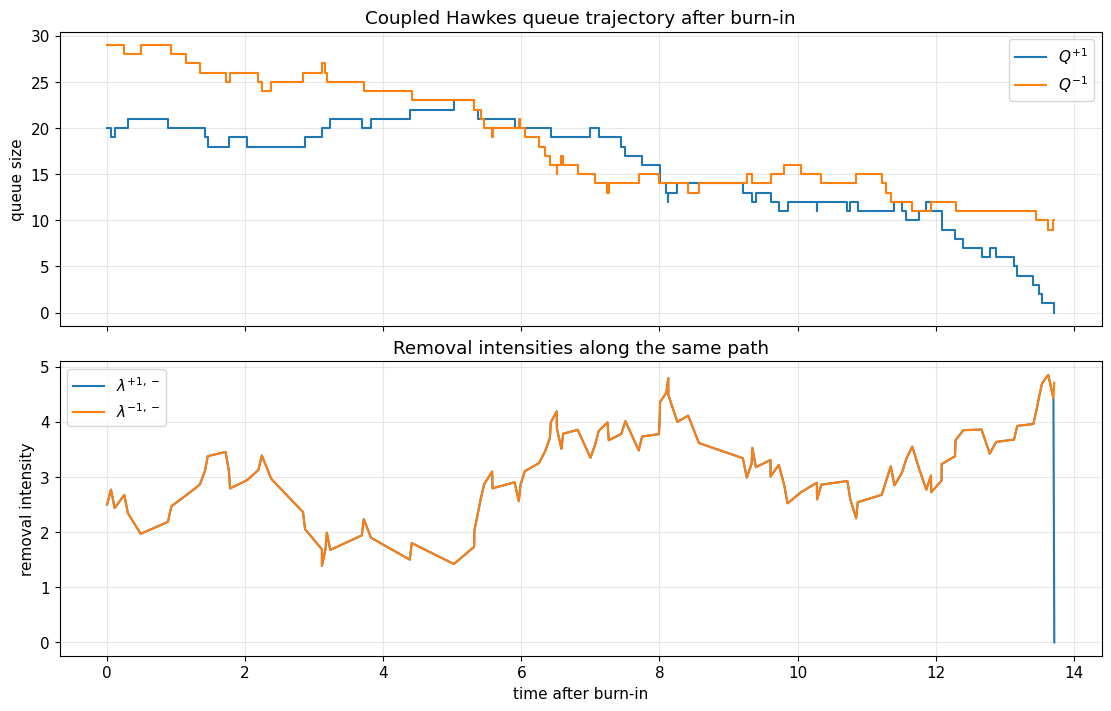

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, layout='constrained')
traj = hawkes_burn_paths[0]
axes[0].step(traj.times, traj.states[:, 0], where='post', label=r'$Q^{+1}$')
axes[0].step(traj.times, traj.states[:, 1], where='post', label=r'$Q^{-1}$')
axes[0].set_title('Coupled Hawkes queue trajectory after burn-in')
axes[0].set_ylabel('queue size')
axes[0].legend()
axes[1].plot(traj.times, traj.intensities[:, 1], label=r'$\lambda^{+1,-}$')
axes[1].plot(traj.times, traj.intensities[:, 3], label=r'$\lambda^{-1,-}$')
axes[1].set_title('Removal intensities along the same path')
axes[1].set_xlabel('time after burn-in')
axes[1].set_ylabel('removal intensity')
axes[1].legend()
plt.show()

**Interprétation.** Le modèle de Hawkes produit des trajectoires plus groupées que le modèle de Poisson. Les périodes de forte intensité de retrait correspondent à des baisses rapides de la file. Cette co-mouvement entre $Q$ et $\lambda^-$ explique pourquoi les temps d'atteinte peuvent changer même si les intensités de base restent proches.

## Distribution des temps d'atteinte

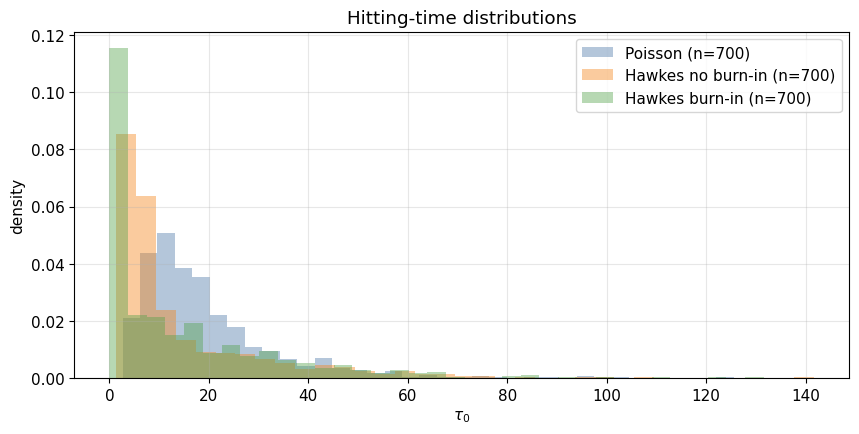

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for label, data, color in [
    ('Poisson', poisson_data['hitting_time'], '#4C78A8'),
    ('Hawkes no burn-in', hawkes_no_data['hitting_time'], '#F58518'),
    ('Hawkes burn-in', hawkes_burn_data['hitting_time'], '#54A24B'),
]:
    ax.hist(data, bins=35, alpha=0.42, density=True, label=f'{label} (n={len(data)})', color=color)
ax.set_title('Hitting-time distributions')
ax.set_xlabel(r'$\tau_0$')
ax.set_ylabel('density')
ax.legend()
plt.show()

**Interprétation.** La comparaison des distributions est plus informative que la seule moyenne. Une masse plus importante près de zéro indique des cascades de retraits; une queue droite plus longue indique des trajectoires où les ajouts compensent longtemps la pression de retrait. Les différences entre burn-in et no burn-in mesurent l'effet de bord lié à l'état d'excitation initial.

## Intensité initiale après burn-in et temps de déplétion

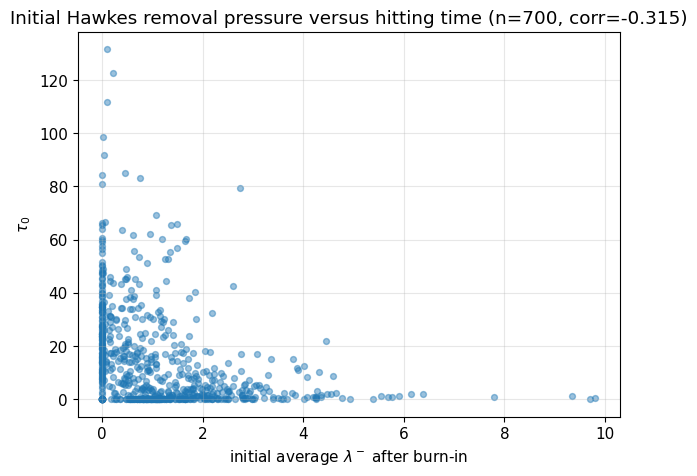

In [7]:
fig, ax = plot_joint_scatter_or_hexbin(
    hawkes_burn_lam0,
    hawkes_burn_data['hitting_time'].to_numpy(dtype=float),
    title='Initial Hawkes removal pressure versus hitting time',
    xlabel=r'initial average $\lambda^-$ after burn-in',
    ylabel=r'$\tau_0$',
)
plt.show()

**Interprétation.** Ce nuage relie l'état d'excitation au début de la fenêtre observée au temps de déplétion. Une pente négative suggérerait que les trajectoires démarrant avec une pression de retrait élevée touchent zéro plus vite. Si le nuage reste très dispersé, cela rappelle que l'état initial de $H$ n'explique qu'une partie de la variabilité : les événements futurs restent aléatoires.

## Diagnostics d'Ogata

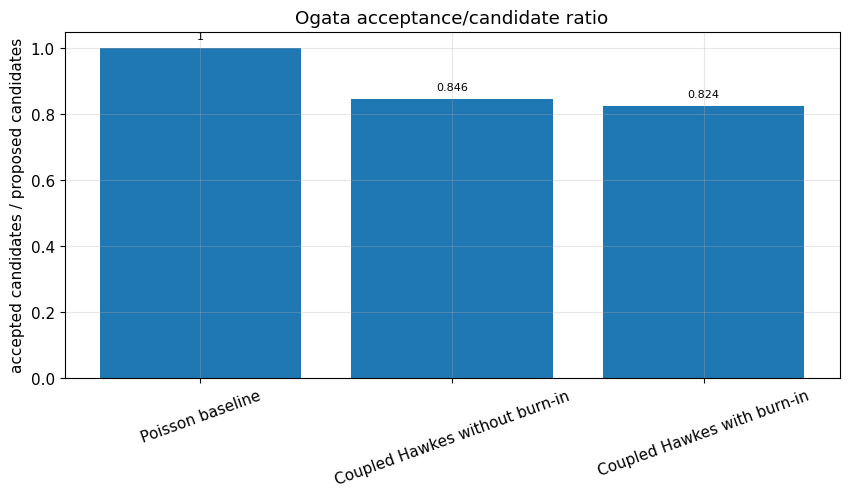

,method,empirical_start_lambda_minus,burn_in,acceptance_candidate_ratio,cpu_seconds,single_queue_stationary_reference
0,Poisson baseline,1.500,0.0,1.000,1.426,1.95
1,Coupled Hawkes without burn-in,1.500,0.0,0.846,1.035,1.95
2,Coupled Hawkes with burn-in,1.177,50.0,0.824,2.941,1.95


In [8]:
fig, ax = safe_barplot_metric(
    comparison_table,
    x='method',
    y='acceptance_candidate_ratio',
    title='Ogata acceptance/candidate ratio',
    ylabel='accepted candidates / proposed candidates',
)
plt.show()

stationarity_empirical = comparison_table[['method', 'empirical_start_lambda_minus', 'burn_in', 'acceptance_candidate_ratio', 'cpu_seconds']].copy()
stationarity_empirical['single_queue_stationary_reference'] = stationary_single_queue
display(format_metric_table(stationarity_empirical, 3))

**Interprétation.** Le ratio accepté/candidat est proche de un dans ce paramétrage, ce qui indique que la borne d'Ogata est efficace. La moyenne empirique de $\lambda^-$ après burn-in est le diagnostic le plus pertinent pour le modèle couplé; la valeur stationnaire mono-file sert seulement de repère, car les deux côtés du carnet interagissent.

## Synthèse nb2

In [9]:
summary_nb2 = pd.DataFrame([
    {
        'empirical_result': 'Hawkes changes first-limit depletion times',
        'theoretical_expectation': 'self-excitation clusters removals',
        'observed_value': f"Poisson mean {poisson_mean:.2f}, burn-in Hawkes mean {hawkes_burn_mean:.2f}",
        'matches_theory': 'coherent with clustered trajectories',
        'caveat': 'finite Monte Carlo and parameter-regime dependent',
    },
    {
        'empirical_result': 'burn-in changes initial intensity state',
        'theoretical_expectation': 'empty-history bias should be reduced',
        'observed_value': f"burn-in {BURN_IN:.1f}",
        'matches_theory': 'diagnosed by empirical_start_lambda_minus',
        'caveat': 'burn-in is not perfect simulation',
    },
])
display(summary_nb2)

,empirical_result,theoretical_expectation,observed_value,matches_theory,caveat
0,Hawkes changes first-limit depletion times,self-excitation clusters removals,"Poisson mean 19.59, burn-in Hawkes mean 14.11",coherent with clustered trajectories,finite Monte Carlo and parameter-regime dependent
1,burn-in changes initial intensity state,empty-history bias should be reduced,burn-in 50.0,diagnosed by empirical_start_lambda_minus,burn-in is not perfect simulation


Les intensités de Hawkes modifient significativement la dynamique de déplétion des premières limites. La question suivante est de savoir ce qui arrive aux deuxièmes limites conditionnellement à cette déplétion.